# ask gpt4v
> ask gpt4v via openai api

In [1]:
#| default_exp ninjalabo.llmcam.ask_gpt4v

In [2]:
#| hide
from nbdev.showdoc import *

In [3]:
#| export
import json
import base64
import requests
from openai import OpenAI

In [4]:
from IPython.display import Image
import glob

In [5]:
files = glob.glob("../data/*.jpg")
len(files), files[:3]

(784,
 ['../data/frame_1728043212.jpg',
  '../data/frame_1728043403.jpg',
  '../data/frame_1728240209.jpg'])

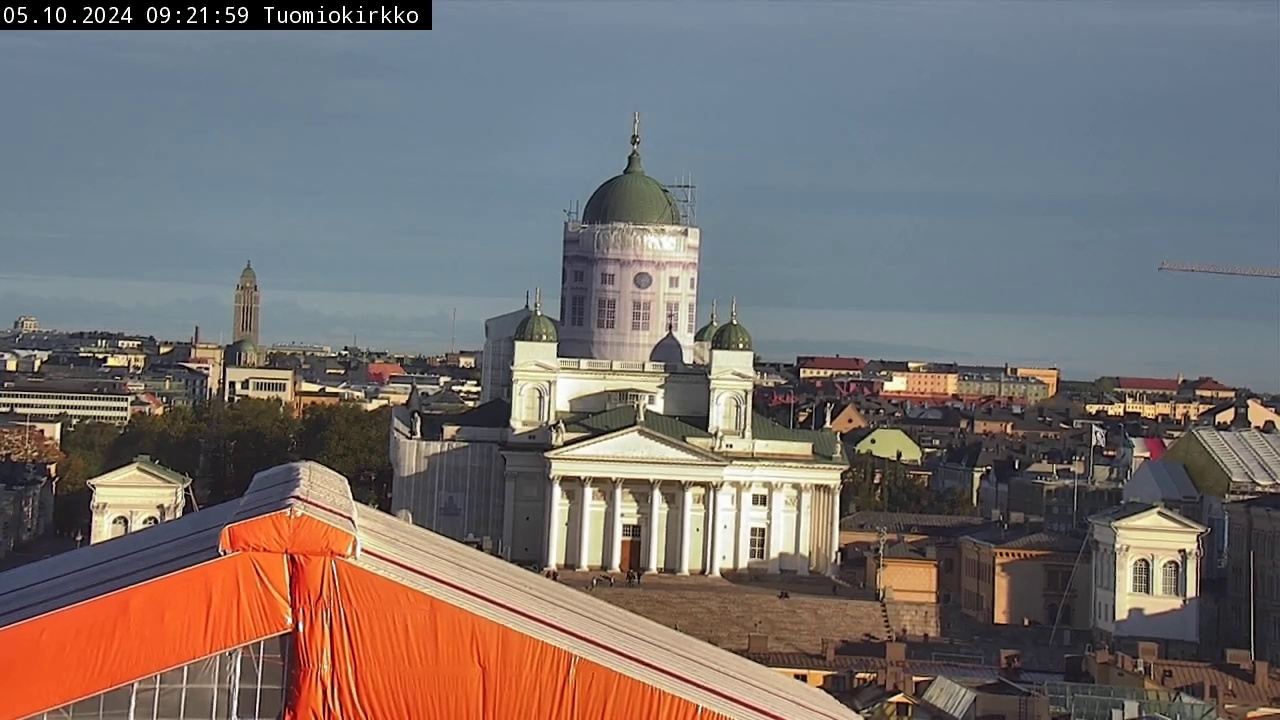

In [6]:
Image(files[-1])

In [7]:
#| export
def encode_image(fname: str):
    "encode an image file as base64"
    with open(fname, "rb") as f:
        return base64.b64encode(f.read()).decode('utf-8')

In [8]:
show_doc(encode_image)

---

### encode_image

>      encode_image (fname:str)

*encode an image file as base64*

In [9]:
base64_image = encode_image(files[0])
base64_image[:9]

'/9j/4AAQS'

In [10]:
#| export
def info(response):
    txt = json.loads(response.json())['choices'][0]['message']['content']
    data = json.loads(txt.replace('```json\n', "").replace('\n```', ""))
    return data

In [11]:
#| export
class openai_inquiry:
    def __init__(self):
        self.client = OpenAI()

    def ask_text(self, question):
        completion = self.client.chat.completions.create(
            model="gpt-4o",
            messages=[
                {"role": "user", "content": question}
            ]
        )
        return completion.choices[0].message.content

    def ask_image(self, fname):

        instruction = """
        Describe this image quantitatively as many as possible in json format.
        
        Here's the example:
        {'timestamp': '2024-10-06T19:04:14',
         'location': 'Kauppatori',
         'dimensions': {'width': 1280, 'height': 720},
         'buildings': {'number_of_buildings': 10,
          'building_height_range': '3-5 stories'},
         'vehicles': {'number_of_vehicles': 5, 'types': ['cars', 'trucks'], number_of_available_parking_space: 3},
         'waterbodies': {'visible': True, 'type': 'harbor', 'number_of_boats': 4},
         'street_lights': {'number_of_street_lights': 20},
         'people': {'approximate_number': 10},
         'lighting': {'time_of_day': 'evening', 'artificial_lighting': 'prominent'},
         'visibility': {'clear': True},
         'sky': {'visible': True, 'light_conditions': 'dusk'}}
        """
        
        response = self.client.chat.completions.create(
          model="gpt-4o",
          messages=[
            {
              "role": "user",
              "content": [
                {
                  "type": "text",
                  "text": instruction,
                },
                {
                  "type": "image_url",
                  "image_url": {
                    "url": f"data:image/jpeg;base64,{encode_image(fname)}",
                    "detail": "high",
                  },
                },
                # {
                #   "type": "image_url",
                #   "image_url": {
                #     "url": f"data:image/jpeg;base64,{encode_image(files[1])}"
                #   },
                # },
              ],
            }
          ],
          max_tokens=300,
        )
        return info(response)

In [12]:
show_doc(openai_inquiry.ask_image)

---

### openai_inquiry.ask_image

>      openai_inquiry.ask_image (fname)

In [ ]:
client = openai_inquiry()
ans = client.ask_text("The capital of France?")
print(ans)
assert "Paris" in ans

The capital of France is Paris.


In [ ]:
ans = client.ask_image("../data/frame_1727529119.jpg")
ans
#FIXME: assert here!

{'timestamp': '2024-09-28T16:05:31',
 'location': 'Olympiaterminaali',
 'dimensions': {'width': 1280, 'height': 720},
 'buildings': {'number_of_buildings': 10,
  'building_height_range': '3-5 stories'},
 'vehicles': {'number_of_vehicles': 25,
  'types': ['cars', 'trucks'],
  'number_of_available_parking_space': 3},
 'waterbodies': {'visible': True, 'type': 'harbor', 'number_of_boats': 2},
 'street_lights': {'number_of_street_lights': 5},
 'people': {'approximate_number': 10},
 'lighting': {'time_of_day': 'afternoon', 'artificial_lighting': 'minimal'},
 'visibility': {'clear': True},
 'sky': {'visible': True, 'light_conditions': 'overcast'}}

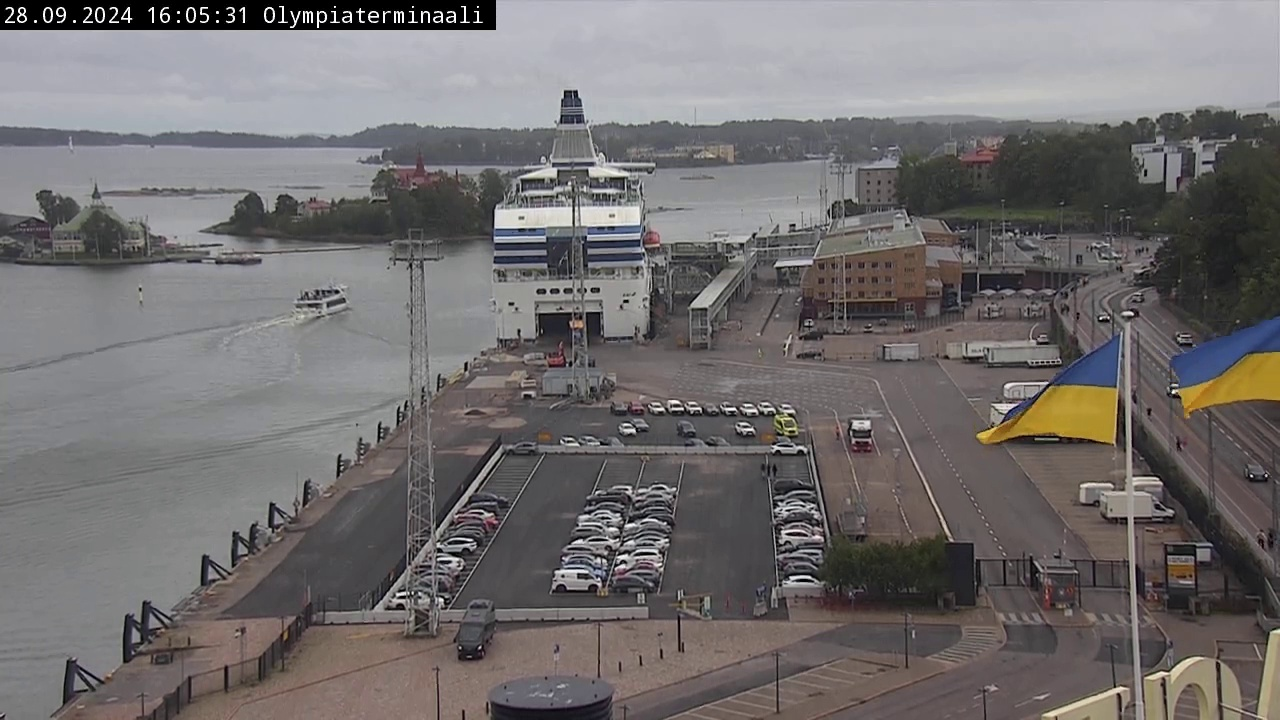

In [ ]:
Image("../data/frame_1727529119.jpg")

In [ ]:
ans = client.ask_image("../data/frame_1728230651.jpg")
ans

{'timestamp': '2024-10-06T18:57:34',
 'location': 'Olympiaterminaali',
 'dimensions': {'width': 1280, 'height': 720},
 'buildings': {'number_of_buildings': 5,
  'building_height_range': '2-4 stories'},
 'vehicles': {'number_of_vehicles': 7,
  'types': ['cars', 'bus', 'truck'],
  'number_of_available_parking_space': 10},
 'waterbodies': {'visible': True, 'type': 'harbor', 'number_of_boats': 2},
 'street_lights': {'number_of_street_lights': 10},
 'people': {'approximate_number': 0},
 'lighting': {'time_of_day': 'evening', 'artificial_lighting': 'prominent'},
 'visibility': {'clear': True},
 'sky': {'visible': True, 'light_conditions': 'dusk'}}

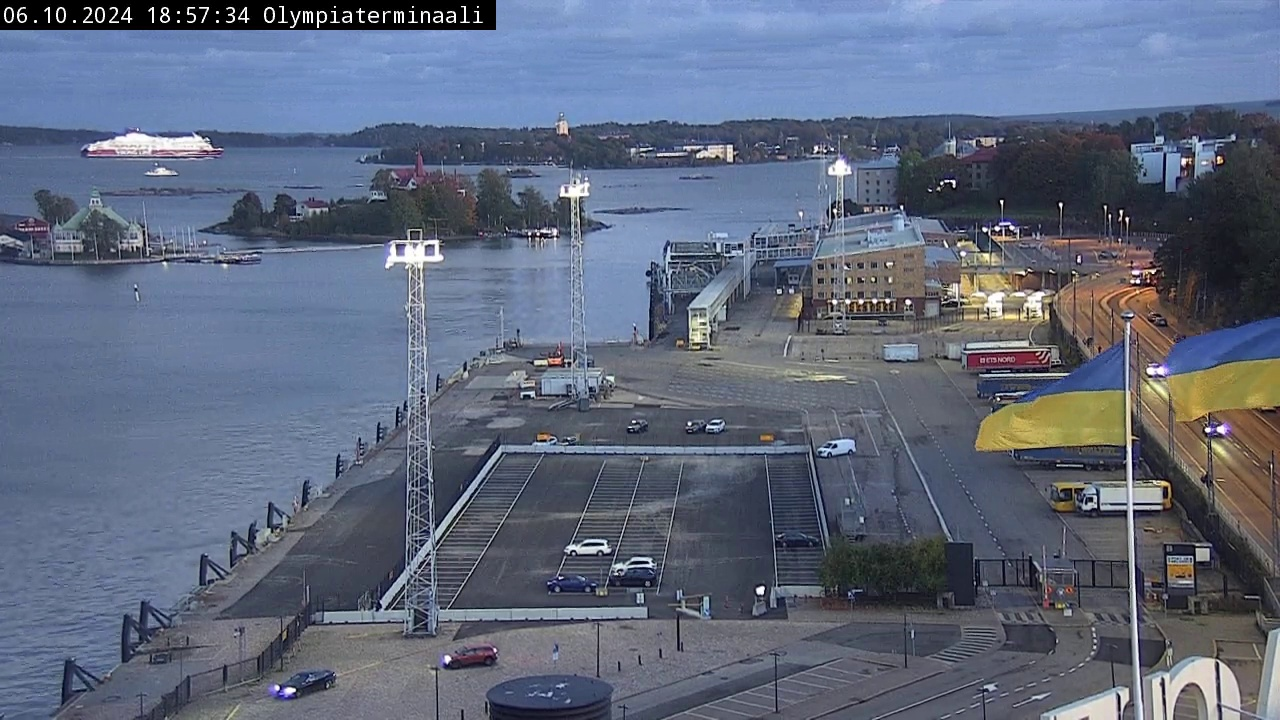

In [ ]:
Image("../data/frame_1728230651.jpg")

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()